# STEMNIST paper figures

This notebook reads the completed training and test results from `outputs/spike/data` and `outputs/pressure/data`, prepares one traceable CSV table for each figure, and exports six publication-oriented SVG figures. All figure text is in English.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator


def find_project_root():
    # 兼容从项目根目录或 Paper_Figure 目录启动 Notebook。
    for candidate in (Path.cwd(), *Path.cwd().parents):
        has_results = (candidate / "outputs" / "spike" / "data").is_dir()
        if has_results and (candidate / "Paper_Figure").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing outputs/.")


PROJECT_ROOT = find_project_root()
PAPER_DIR = PROJECT_ROOT / "Paper_Figure"
FIGURE_DIR = PAPER_DIR / "figures"
DATA_DIR = PAPER_DIR / "data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_DIRS = {
    "spike": PROJECT_ROOT / "outputs" / "spike" / "data",
    "pressure": PROJECT_ROOT / "outputs" / "pressure" / "data",
}
DATASET_LABELS = {
    "spike": "Spike-Encoded",
    "pressure": "Raw Pressure",
}
DATASET_COLORS = {
    "spike": "#0072B2",
    "pressure": "#D55E00",
}
SPLIT_STYLES = {"Train": "-", "Val": "--"}
CLASS_ORDER = [*list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"), *list("123456789")]

mpl.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.45,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "svg.hashsalt": "stemnist-paper-figures",
        "savefig.facecolor": "white",
        "figure.facecolor": "white",
    }
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figure output: {FIGURE_DIR}")
print(f"Data output: {DATA_DIR}")

Project root: C:\Users\Fortyfour\Desktop\STEMNIST_Ready
Figure output: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures
Data output: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\data


In [2]:
def read_source_tables(source_dir):
    tables = {
        "history": pd.read_csv(source_dir / "history.csv"),
        "test_metrics": pd.read_csv(source_dir / "test_metrics.csv"),
        "confusion": pd.read_csv(source_dir / "confusion_matrix.csv"),
        "per_class": pd.read_csv(source_dir / "per_class_accuracy.csv"),
    }
    if len(tables["test_metrics"]) != 1:
        raise ValueError(f"Expected one test_metrics row in {source_dir}.")
    return tables


def validate_source_tables(kind, tables):
    history = tables["history"]
    metrics = tables["test_metrics"].iloc[0]
    confusion = tables["confusion"]
    per_class = tables["per_class"]

    history_columns = {"epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"}
    if missing := history_columns.difference(history.columns):
        raise ValueError(f"{kind} history is missing columns: {sorted(missing)}")
    if not history["epoch"].is_monotonic_increasing or history["epoch"].duplicated().any():
        raise ValueError(f"{kind} epochs must be unique and increasing.")
    if per_class["label"].tolist() != CLASS_ORDER:
        raise ValueError(f"{kind} class order does not match A-Z, 1-9.")
    if confusion["true_label"].tolist() != CLASS_ORDER:
        raise ValueError(f"{kind} confusion-matrix row order is invalid.")

    predicted_columns = [f"pred_{label}" for label in CLASS_ORDER]
    counts = confusion[predicted_columns].to_numpy(dtype=int)
    if not np.array_equal(counts.sum(axis=1), per_class["samples"].to_numpy(dtype=int)):
        raise ValueError(f"{kind} confusion row totals do not match per-class sample counts.")
    if not np.array_equal(np.diag(counts), per_class["correct"].to_numpy(dtype=int)):
        raise ValueError(f"{kind} confusion diagonal does not match per-class correct counts.")

    checkpoint_epoch = int(metrics["checkpoint_epoch"])
    checkpoint_rows = history.loc[history["epoch"] == checkpoint_epoch]
    if len(checkpoint_rows) != 1:
        raise ValueError(f"{kind} checkpoint epoch is absent from history.")
    checkpoint_val = float(checkpoint_rows.iloc[0]["val_accuracy"])
    if not np.isclose(checkpoint_val, float(metrics["best_val_accuracy"])):
        raise ValueError(f"{kind} checkpoint validation accuracy is inconsistent.")
    measured_test_accuracy = np.trace(counts) / counts.sum()
    if not np.isclose(measured_test_accuracy, float(metrics["test_accuracy"])):
        raise ValueError(f"{kind} test accuracy is inconsistent with the confusion matrix.")


source_tables = {kind: read_source_tables(path) for kind, path in SOURCE_DIRS.items()}
for kind, tables in source_tables.items():
    validate_source_tables(kind, tables)

summary_rows = []
for kind, tables in source_tables.items():
    metrics = tables["test_metrics"].iloc[0]
    summary_rows.append(
        {
            "Dataset": DATASET_LABELS[kind],
            "Epochs": len(tables["history"]),
            "Checkpoint epoch": int(metrics["checkpoint_epoch"]),
            "Best val accuracy": float(metrics["best_val_accuracy"]),
            "Test accuracy": float(metrics["test_accuracy"]),
        }
    )
pd.DataFrame(summary_rows)

,Dataset,Epochs,Checkpoint epoch,Best val accuracy,Test accuracy
0,Spike-Encoded,100,71,0.941991,0.926407
1,Raw Pressure,100,96,0.643290,0.607792


## Figure 1 — training, validation, and test performance

Color identifies the input representation, line style identifies the Train/Val split, and sparse markers distinguish Accuracy curves from Loss curves. Test accuracy is plotted only at the epoch stored by the corresponding best-model checkpoint.

In [3]:
figure1_rows = []
for kind, tables in source_tables.items():
    history = tables["history"]
    for split, prefix in (("Train", "train"), ("Val", "val")):
        for row in history.itertuples(index=False):
            accuracy = float(getattr(row, f"{prefix}_accuracy"))
            figure1_rows.append(
                {
                    "dataset": DATASET_LABELS[kind],
                    "split": split,
                    "epoch": int(row.epoch),
                    "loss": float(getattr(row, f"{prefix}_loss")),
                    "accuracy": accuracy,
                    "accuracy_percent": 100.0 * accuracy,
                    "plotted_as_test_marker": False,
                }
            )

    metrics = tables["test_metrics"].iloc[0]
    test_accuracy = float(metrics["test_accuracy"])
    figure1_rows.append(
        {
            "dataset": DATASET_LABELS[kind],
            "split": "Test",
            "epoch": int(metrics["checkpoint_epoch"]),
            "loss": float(metrics["test_loss"]),
            "accuracy": test_accuracy,
            "accuracy_percent": 100.0 * test_accuracy,
            "plotted_as_test_marker": True,
        }
    )

figure1_data = pd.DataFrame(figure1_rows)
figure1_csv = DATA_DIR / "figure1_training_curves.csv"
figure1_data.to_csv(figure1_csv, index=False, float_format="%.10g")
figure1_data.tail()

,dataset,split,epoch,loss,accuracy,accuracy_percent,plotted_as_test_marker
397,Raw Pressure,Val,97,1.345940,0.612121,61.212121,False
398,Raw Pressure,Val,98,1.329216,0.625974,62.597403,False
399,Raw Pressure,Val,99,1.329016,0.622511,62.251082,False
400,Raw Pressure,Val,100,1.330539,0.636364,63.636364,False
401,Raw Pressure,Test,96,1.332453,0.607792,60.779221,True


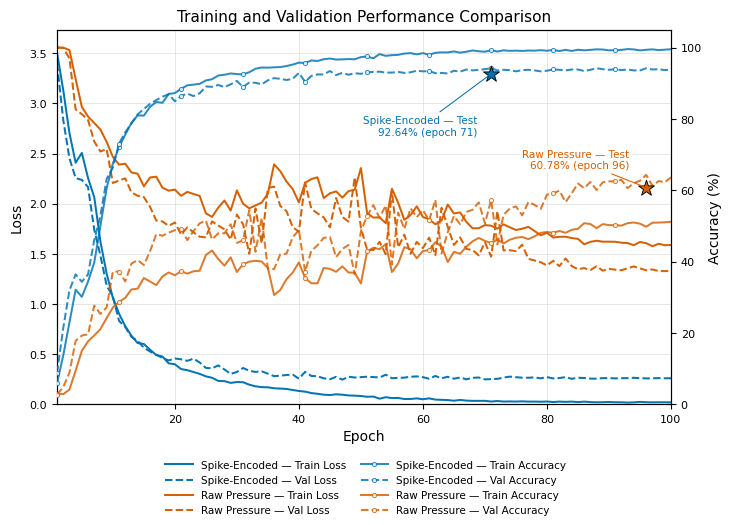

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure1_training_curves.svg


In [4]:
figure1_svg = FIGURE_DIR / "figure1_training_curves.svg"
fig, loss_axis = plt.subplots(figsize=(7.2, 5.15), layout="constrained")
accuracy_axis = loss_axis.twinx()
line_handles = []
line_labels = []

for metric, axis, marker in (
    ("Loss", loss_axis, None),
    ("Accuracy", accuracy_axis, "o"),
):
    value_column = "loss" if metric == "Loss" else "accuracy_percent"
    for kind in ("spike", "pressure"):
        dataset = DATASET_LABELS[kind]
        for split in ("Train", "Val"):
            subset = figure1_data.loc[
                (figure1_data["dataset"] == dataset)
                & (figure1_data["split"] == split)
            ]
            line, = axis.plot(
                subset["epoch"],
                subset[value_column],
                color=DATASET_COLORS[kind],
                linestyle=SPLIT_STYLES[split],
                marker=marker,
                markevery=10 if marker else None,
                markersize=3.0,
                markerfacecolor="white",
                markeredgewidth=0.7,
                alpha=0.98 if metric == "Loss" else 0.82,
                zorder=2 if metric == "Loss" else 3,
            )
            line_handles.append(line)
            line_labels.append(f"{dataset} — {split} {metric}")

annotation_offsets = {
    "Spike-Encoded": (-10, -38),
    "Raw Pressure": (-12, 20),
}
for kind in ("spike", "pressure"):
    dataset = DATASET_LABELS[kind]
    test_row = figure1_data.loc[
        (figure1_data["dataset"] == dataset)
        & (figure1_data["split"] == "Test")
    ].iloc[0]
    epoch = int(test_row["epoch"])
    accuracy = float(test_row["accuracy_percent"])
    accuracy_axis.scatter(
        epoch,
        accuracy,
        marker="*",
        s=145,
        color=DATASET_COLORS[kind],
        edgecolor="black",
        linewidth=0.65,
        zorder=8,
    )
    accuracy_axis.annotate(
        f"{dataset} — Test\n{accuracy:.2f}% (epoch {epoch})",
        xy=(epoch, accuracy),
        xytext=annotation_offsets[dataset],
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=7.5,
        color=DATASET_COLORS[kind],
        arrowprops={"arrowstyle": "-", "color": DATASET_COLORS[kind], "lw": 0.75},
        bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "none", "alpha": 0.88},
        zorder=9,
    )

loss_axis.set(
    title="Training and Validation Performance Comparison",
    xlabel="Epoch",
    ylabel="Loss",
    xlim=(1, int(figure1_data.loc[figure1_data["split"] != "Test", "epoch"].max())),
)
loss_axis.set_ylim(bottom=0)
accuracy_axis.set_ylabel("Accuracy (%)")
accuracy_axis.set_ylim(0, 105)
accuracy_axis.yaxis.set_major_locator(MultipleLocator(20))
loss_axis.grid(axis="both", color="#D9D9D9", linewidth=0.6, alpha=0.75)
loss_axis.set_axisbelow(True)

# 八条曲线使用显式标签，避免双 Y 轴下的指标归属产生歧义。
fig.legend(
    line_handles,
    line_labels,
    loc="outside lower center",
    ncols=2,
    frameon=False,
    columnspacing=1.4,
    handlelength=2.6,
)
fig.savefig(figure1_svg, format="svg", metadata={"Creator": "Matplotlib", "Date": None})
plt.show()
print(f"Saved: {figure1_svg}")

## Figures 2 and 3 — normalized confusion matrices

Each row is normalized independently, so a cell reports the percentage of samples from one true class assigned to a predicted class. Both figures use the same fixed 0–100% color scale.

In [5]:
def prepare_confusion_data(kind, output_name):
    confusion = source_tables[kind]["confusion"]
    predicted_columns = [f"pred_{label}" for label in CLASS_ORDER]
    counts = confusion[predicted_columns].to_numpy(dtype=int)
    row_totals = counts.sum(axis=1, keepdims=True)
    percentages = np.divide(
        counts * 100.0,
        row_totals,
        out=np.zeros_like(counts, dtype=float),
        where=row_totals != 0,
    )

    rows = []
    for true_index, true_class in enumerate(CLASS_ORDER):
        for predicted_index, predicted_class in enumerate(CLASS_ORDER):
            rows.append(
                {
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": int(counts[true_index, predicted_index]),
                    "true_class_total": int(row_totals[true_index, 0]),
                    "row_proportion": percentages[true_index, predicted_index] / 100.0,
                    "row_percentage": percentages[true_index, predicted_index],
                }
            )
    long_data = pd.DataFrame(rows)
    output_path = DATA_DIR / output_name
    long_data.to_csv(output_path, index=False, float_format="%.10g")
    return long_data, output_path


spike_confusion_data, figure2_csv = prepare_confusion_data(
    "spike", "figure2_spike_confusion_matrix.csv"
)
pressure_confusion_data, figure3_csv = prepare_confusion_data(
    "pressure", "figure3_raw_pressure_confusion_matrix.csv"
)

print(f"Saved: {figure2_csv}")
print(f"Saved: {figure3_csv}")
spike_confusion_data.head()

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\data\figure2_spike_confusion_matrix.csv
Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\data\figure3_raw_pressure_confusion_matrix.csv


,true_class,predicted_class,count,true_class_total,row_proportion,row_percentage
0,A,A,31,33,0.939394,93.939394
1,A,B,0,33,0.000000,0.000000
2,A,C,0,33,0.000000,0.000000
3,A,D,0,33,0.000000,0.000000
4,A,E,0,33,0.000000,0.000000


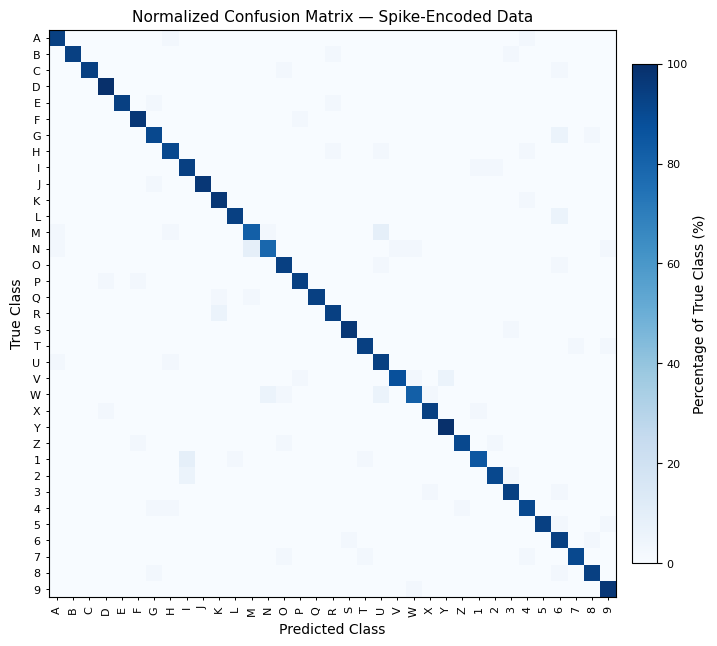

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure2_spike_confusion_matrix.svg


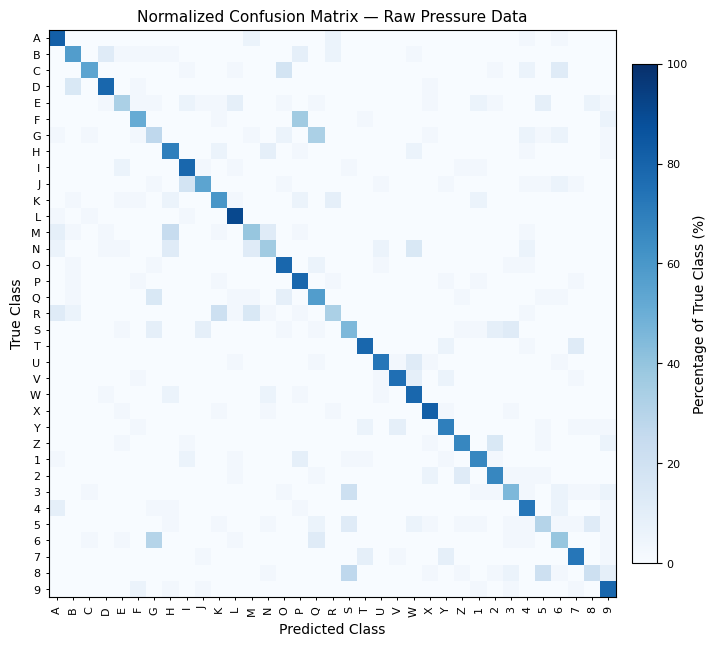

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure3_raw_pressure_confusion_matrix.svg


In [6]:
def plot_normalized_confusion(long_data, title, output_name):
    matrix = (
        long_data.pivot(index="true_class", columns="predicted_class", values="row_percentage")
        .reindex(index=CLASS_ORDER, columns=CLASS_ORDER)
        .to_numpy()
    )

    fig, axis = plt.subplots(figsize=(7.2, 6.35), layout="constrained")
    image = axis.pcolormesh(
        matrix,
        cmap="Blues",
        vmin=0.0,
        vmax=100.0,
        shading="flat",
        edgecolors="none",
    )
    positions = np.arange(len(CLASS_ORDER)) + 0.5
    axis.set_xticks(positions, CLASS_ORDER, rotation=90)
    axis.set_yticks(positions, CLASS_ORDER)
    axis.invert_yaxis()
    axis.set_aspect("equal")
    axis.set(
        title=title,
        xlabel="Predicted Class",
        ylabel="True Class",
    )
    axis.tick_params(length=2.5, width=0.7)
    colorbar = fig.colorbar(image, ax=axis, shrink=0.88, pad=0.025)
    colorbar.set_label("Percentage of True Class (%)")
    # Matplotlib 默认会栅格化连续色条；这里关闭栅格化以保持纯矢量 SVG。
    colorbar.solids.set_rasterized(False)
    colorbar.set_ticks(np.arange(0, 101, 20))

    output_path = FIGURE_DIR / output_name
    fig.savefig(output_path, format="svg", metadata={"Creator": "Matplotlib", "Date": None})
    plt.show()
    print(f"Saved: {output_path}")
    return output_path


figure2_svg = plot_normalized_confusion(
    spike_confusion_data,
    "Normalized Confusion Matrix — Spike-Encoded Data",
    "figure2_spike_confusion_matrix.svg",
)
figure3_svg = plot_normalized_confusion(
    pressure_confusion_data,
    "Normalized Confusion Matrix — Raw Pressure Data",
    "figure3_raw_pressure_confusion_matrix.svg",
)

## Figure 4 — per-class test accuracy

Grouped bars compare the two input representations on the same percentage scale. Color and hatch are both used so that the comparison does not depend on color alone.

In [7]:
spike_per_class = source_tables["spike"]["per_class"].set_index("label").reindex(CLASS_ORDER)
pressure_per_class = source_tables["pressure"]["per_class"].set_index("label").reindex(CLASS_ORDER)

figure4_data = pd.DataFrame(
    {
        "class": CLASS_ORDER,
        "spike_encoded_samples": spike_per_class["samples"].to_numpy(dtype=int),
        "spike_encoded_correct": spike_per_class["correct"].to_numpy(dtype=int),
        "spike_encoded_accuracy": spike_per_class["accuracy"].to_numpy(dtype=float),
        "spike_encoded_accuracy_percent": 100.0 * spike_per_class["accuracy"].to_numpy(dtype=float),
        "raw_pressure_samples": pressure_per_class["samples"].to_numpy(dtype=int),
        "raw_pressure_correct": pressure_per_class["correct"].to_numpy(dtype=int),
        "raw_pressure_accuracy": pressure_per_class["accuracy"].to_numpy(dtype=float),
        "raw_pressure_accuracy_percent": 100.0 * pressure_per_class["accuracy"].to_numpy(dtype=float),
    }
)
figure4_csv = DATA_DIR / "figure4_per_class_accuracy.csv"
figure4_data.to_csv(figure4_csv, index=False, float_format="%.10g")
figure4_data.head()

,class,spike_encoded_samples,spike_encoded_correct,spike_encoded_accuracy,spike_encoded_accuracy_percent,raw_pressure_samples,raw_pressure_correct,raw_pressure_accuracy,raw_pressure_accuracy_percent
0,A,33,31,0.939394,93.939394,33,27,0.818182,81.818182
1,B,33,31,0.939394,93.939394,33,19,0.575758,57.575758
2,C,33,31,0.939394,93.939394,33,18,0.545455,54.545455
3,D,33,33,1.000000,100.000000,33,26,0.787879,78.787879
4,E,33,31,0.939394,93.939394,33,11,0.333333,33.333333


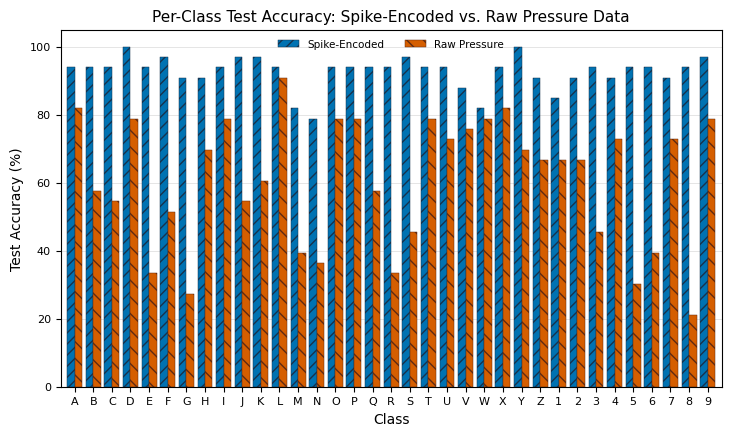

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure4_per_class_accuracy.svg


In [8]:
figure4_svg = FIGURE_DIR / "figure4_per_class_accuracy.svg"
positions = np.arange(len(CLASS_ORDER))
bar_width = 0.40

fig, axis = plt.subplots(figsize=(7.2, 4.25), layout="constrained")
axis.bar(
    positions - bar_width / 2,
    figure4_data["spike_encoded_accuracy_percent"],
    width=bar_width,
    label="Spike-Encoded",
    color=DATASET_COLORS["spike"],
    edgecolor="#17324D",
    linewidth=0.35,
    hatch="///",
)
axis.bar(
    positions + bar_width / 2,
    figure4_data["raw_pressure_accuracy_percent"],
    width=bar_width,
    label="Raw Pressure",
    color=DATASET_COLORS["pressure"],
    edgecolor="#5F2A13",
    linewidth=0.35,
    hatch="\\\\",
)
axis.set_xticks(positions, CLASS_ORDER)
axis.set(
    title="Per-Class Test Accuracy: Spike-Encoded vs. Raw Pressure Data",
    xlabel="Class",
    ylabel="Test Accuracy (%)",
    ylim=(0, 105),
    xlim=(-0.75, len(CLASS_ORDER) - 0.25),
)
axis.yaxis.set_major_locator(MultipleLocator(20))
axis.grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.8)
axis.set_axisbelow(True)
axis.legend(loc="upper center", ncols=2, frameon=False)
fig.savefig(figure4_svg, format="svg", metadata={"Creator": "Matplotlib", "Date": None})
plt.show()
print(f"Saved: {figure4_svg}")

## Figure 5 — accuracy-only training curves

Train, Val, and Test are encoded by color. Line style and marker shape distinguish Spike-Encoded from Raw Pressure, while direct annotations identify the two Test points.

In [9]:
figure5_data = figure1_data[
    ["dataset", "split", "epoch", "accuracy", "accuracy_percent", "plotted_as_test_marker"]
].copy()
figure5_csv = DATA_DIR / "figure5_training_curves(only acc).csv"
figure5_data.to_csv(figure5_csv, index=False, float_format="%.10g")
figure5_data.tail()

,dataset,split,epoch,accuracy,accuracy_percent,plotted_as_test_marker
397,Raw Pressure,Val,97,0.612121,61.212121,False
398,Raw Pressure,Val,98,0.625974,62.597403,False
399,Raw Pressure,Val,99,0.622511,62.251082,False
400,Raw Pressure,Val,100,0.636364,63.636364,False
401,Raw Pressure,Test,96,0.607792,60.779221,True


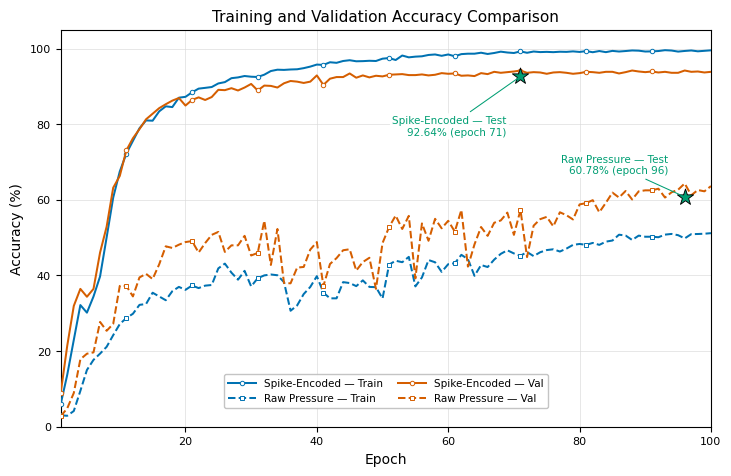

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure5_training_curves(only acc).svg


In [10]:
figure5_svg = FIGURE_DIR / "figure5_training_curves(only acc).svg"
split_colors = {
    "Train": "#0072B2",
    "Val": "#D55E00",
    "Test": "#009E73",
}
dataset_styles = {
    "Spike-Encoded": {"linestyle": "-", "marker": "o"},
    "Raw Pressure": {"linestyle": "--", "marker": "s"},
}

fig, axis = plt.subplots(figsize=(7.2, 4.65), layout="constrained")
for split in ("Train", "Val"):
    for dataset in ("Spike-Encoded", "Raw Pressure"):
        subset = figure5_data.loc[
            (figure5_data["dataset"] == dataset)
            & (figure5_data["split"] == split)
        ]
        style = dataset_styles[dataset]
        axis.plot(
            subset["epoch"],
            subset["accuracy_percent"],
            color=split_colors[split],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markevery=10,
            markersize=3.2,
            markerfacecolor="white",
            markeredgewidth=0.7,
            label=f"{dataset} — {split}",
            zorder=3,
        )

test_offsets = {
    "Spike-Encoded": (-10, -36),
    "Raw Pressure": (-12, 23),
}
for dataset in ("Spike-Encoded", "Raw Pressure"):
    test_row = figure5_data.loc[
        (figure5_data["dataset"] == dataset)
        & (figure5_data["split"] == "Test")
    ].iloc[0]
    epoch = int(test_row["epoch"])
    accuracy = float(test_row["accuracy_percent"])
    axis.scatter(
        epoch,
        accuracy,
        marker="*",
        s=150,
        color=split_colors["Test"],
        edgecolor="black",
        linewidth=0.65,
        zorder=8,
    )
    axis.annotate(
        f"{dataset} — Test\n{accuracy:.2f}% (epoch {epoch})",
        xy=(epoch, accuracy),
        xytext=test_offsets[dataset],
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=7.5,
        color=split_colors["Test"],
        arrowprops={"arrowstyle": "-", "color": split_colors["Test"], "lw": 0.75},
        bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "none", "alpha": 0.9},
        zorder=9,
    )

axis.set(
    title="Training and Validation Accuracy Comparison",
    xlabel="Epoch",
    ylabel="Accuracy (%)",
    xlim=(1, int(figure5_data.loc[figure5_data["split"] != "Test", "epoch"].max())),
    ylim=(0, 105),
)
axis.yaxis.set_major_locator(MultipleLocator(20))
axis.grid(axis="both", color="#D9D9D9", linewidth=0.6, alpha=0.75)
axis.set_axisbelow(True)
# 曲线中下部留白最大，图例置于此处以保持在图内且不遮挡主要数据。
axis.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.035),
    ncols=2,
    frameon=True,
    facecolor="white",
    edgecolor="#BFBFBF",
    framealpha=0.92,
    columnspacing=1.4,
    handlelength=2.7,
)
fig.savefig(figure5_svg, format="svg", metadata={"Creator": "Matplotlib", "Date": None})
plt.show()
print(f"Saved: {figure5_svg}")

## Figure 6 — loss-only training curves

Train, Val, and Test are encoded by color. Line style and marker shape distinguish Spike-Encoded from Raw Pressure, while direct annotations identify the two Test points.

In [11]:
figure6_data = figure1_data[
    ["dataset", "split", "epoch", "loss", "plotted_as_test_marker"]
].copy()
figure6_csv = DATA_DIR / "figure6_training_curves(only loss).csv"
figure6_data.to_csv(figure6_csv, index=False, float_format="%.10g")
figure6_data.tail()

,dataset,split,epoch,loss,plotted_as_test_marker
397,Raw Pressure,Val,97,1.345940,False
398,Raw Pressure,Val,98,1.329216,False
399,Raw Pressure,Val,99,1.329016,False
400,Raw Pressure,Val,100,1.330539,False
401,Raw Pressure,Test,96,1.332453,True


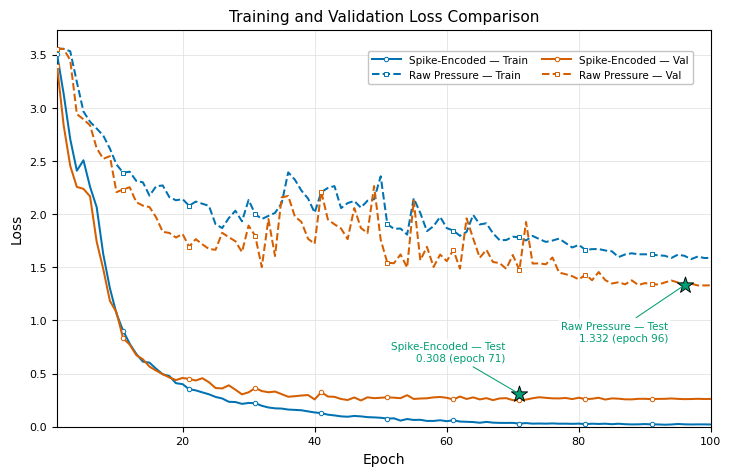

Saved: C:\Users\Fortyfour\Desktop\STEMNIST_Ready\Paper_Figure\figures\figure6_training_curves(only loss).svg


In [12]:
figure6_svg = FIGURE_DIR / "figure6_training_curves(only loss).svg"
loss_split_colors = {
    "Train": "#0072B2",
    "Val": "#D55E00",
    "Test": "#009E73",
}
loss_dataset_styles = {
    "Spike-Encoded": {"linestyle": "-", "marker": "o"},
    "Raw Pressure": {"linestyle": "--", "marker": "s"},
}

fig, axis = plt.subplots(figsize=(7.2, 4.65), layout="constrained")
for split in ("Train", "Val"):
    for dataset in ("Spike-Encoded", "Raw Pressure"):
        subset = figure6_data.loc[
            (figure6_data["dataset"] == dataset)
            & (figure6_data["split"] == split)
        ]
        style = loss_dataset_styles[dataset]
        axis.plot(
            subset["epoch"],
            subset["loss"],
            color=loss_split_colors[split],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markevery=10,
            markersize=3.2,
            markerfacecolor="white",
            markeredgewidth=0.7,
            label=f"{dataset} — {split}",
            zorder=3,
        )

test_offsets = {
    "Spike-Encoded": (-10, 30),
    "Raw Pressure": (-12, -34),
}
for dataset in ("Spike-Encoded", "Raw Pressure"):
    test_row = figure6_data.loc[
        (figure6_data["dataset"] == dataset)
        & (figure6_data["split"] == "Test")
    ].iloc[0]
    epoch = int(test_row["epoch"])
    test_loss = float(test_row["loss"])
    axis.scatter(
        epoch,
        test_loss,
        marker="*",
        s=150,
        color=loss_split_colors["Test"],
        edgecolor="black",
        linewidth=0.65,
        zorder=8,
    )
    axis.annotate(
        f"{dataset} — Test\n{test_loss:.3f} (epoch {epoch})",
        xy=(epoch, test_loss),
        xytext=test_offsets[dataset],
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=7.5,
        color=loss_split_colors["Test"],
        arrowprops={"arrowstyle": "-", "color": loss_split_colors["Test"], "lw": 0.75},
        bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "none", "alpha": 0.9},
        zorder=9,
    )

maximum_loss = figure6_data.loc[figure6_data["split"] != "Test", "loss"].max()
axis.set(
    title="Training and Validation Loss Comparison",
    xlabel="Epoch",
    ylabel="Loss",
    xlim=(1, int(figure6_data.loc[figure6_data["split"] != "Test", "epoch"].max())),
    ylim=(0, maximum_loss * 1.05),
)
axis.grid(axis="both", color="#D9D9D9", linewidth=0.6, alpha=0.75)
axis.set_axisbelow(True)
# 训练后半程的高损失区域为空白，图例置于右上角以避开曲线和测试标记。
axis.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.96),
    ncols=2,
    frameon=True,
    facecolor="white",
    edgecolor="#BFBFBF",
    framealpha=0.92,
    columnspacing=1.4,
    handlelength=2.7,
)
fig.savefig(figure6_svg, format="svg", metadata={"Creator": "Matplotlib", "Date": None})
plt.show()
print(f"Saved: {figure6_svg}")

In [13]:
expected_outputs = [
    figure1_svg,
    figure2_svg,
    figure3_svg,
    figure4_svg,
    figure5_svg,
    figure6_svg,
    figure1_csv,
    figure2_csv,
    figure3_csv,
    figure4_csv,
    figure5_csv,
    figure6_csv,
]
for path in expected_outputs:
    if not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f"Missing or empty output: {path}")

# SVG 中保留可编辑文本；连续色条可能由 Matplotlib 以小型栅格渐变嵌入。
for svg_path in expected_outputs[:6]:
    svg_text = svg_path.read_text(encoding="utf-8")
    if "<text" not in svg_text:
        raise RuntimeError(f"SVG text was converted to paths: {svg_path}")

audit = pd.DataFrame(
    {
        "output": [str(path.relative_to(PROJECT_ROOT)) for path in expected_outputs],
        "size_bytes": [path.stat().st_size for path in expected_outputs],
        "contains_embedded_raster": [
            path.suffix.lower() == ".svg" and "data:image" in path.read_text(encoding="utf-8")
            for path in expected_outputs
        ],
    }
)
audit

,output,size_bytes,contains_embedded_raster
0,Paper_Figure\figures\figure1_training_curves.svg,52440,False
1,Paper_Figure\figures\figure2_spike_confusion_m...,326272,False
2,Paper_Figure\figures\figure3_raw_pressure_conf...,326271,False
3,Paper_Figure\figures\figure4_per_class_accurac...,42806,False
4,Paper_Figure\figures\figure5_training_curves(o...,33634,False
5,Paper_Figure\figures\figure6_training_curves(o...,35047,False
6,Paper_Figure\data\figure1_training_curves.csv,26486,False
7,Paper_Figure\data\figure2_spike_confusion_matr...,19423,False
8,Paper_Figure\data\figure3_raw_pressure_confusi...,23112,False
9,Paper_Figure\data\figure4_per_class_accuracy.csv,2428,False


## Methodology reference

Kassis, T., Agarwal, V., He, Y., Patel, D., & Brueckner, A. M. (2026). *Scientific Agent Skills: A Library of Procedural Knowledge for Research Agents*. arXiv:2609.00065. https://doi.org/10.48550/arXiv.2609.00065